In [1]:
# Setup path and load utils
import sys, os
sys.path.append(os.path.abspath("../src"))
import numpy as np
print("Current working directory:", os.getcwd())
import sys
for p in sys.path:
    print(p)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

Current working directory: /home/isesdr/Downloads/ble-RFFingerprinting/notebooks
/usr/lib/python311.zip
/usr/lib/python3.11
/usr/lib/python3.11/lib-dynload

/home/isesdr/Downloads/ble-RFFingerprinting/ble-rff-env/lib/python3.11/site-packages
/home/isesdr/Downloads/ble-RFFingerprinting/src


In [ ]:
# Extract the features from the labelled bursts

from feature import IQFeatureExtractor
from utils import list_npys_by_timestamp, load_iq_burst

# Feature extraction
extractor = IQFeatureExtractor()
records = []

for filename, timestamp, address in list_npys_by_timestamp("../disk/packets"):
    samples = load_iq_burst(f"../disk/packets/{filename}")
    features = extractor.compute_features(samples)
    features['timestamp'] = timestamp
    features['address'] = address
    records.append(features)

df_features = pd.DataFrame(records)
df_features.to_csv("../disk/features.csv", index=False)
print(df_features.columns.tolist())  # <- Confirm all fields

address
CB:ED:4C:B9:8A:74    3378
FB:AA:97:52:35:AA    3269
F2:03:74:67:C3:96    3260
EC:19:06:6D:B6:7B    3243
FD:7C:7A:7D:B4:42    3227
FF:BC:6A:9A:43:D5    3028
F1:07:9E:12:57:84    2987
C7:2C:2A:BD:C2:53      39
FF:49:EC:FC:B2:D5      20
FE:60:ED:58:77:4A      12
FD:7C:7A:7D:94:42       1
FD:7C:7A:7D:A4:42       1
FD:7C:7A:7D:B4:52       1
FB:AA:97:52:35:2A       1
FB:AA:97:12:35:AA       1
FB:AA:87:52:35:AA       1
FB:AA:97:53:35:AA       1
12:83:F5:C0:60:07       1
F2:03:74:67:C1:96       1
14:24:FA:13:55:58       1
CB:ED:4C:B9:0A:74       1
CB:ED:4C:A9:8A:74       1
AF:BC:6A:9A:43:D5       1
AE:55:2F:0A:8C:87       1
7F:1D:70:6F:82:25       1
78:A5:89:32:8C:A5       1
69:14:0A:AC:A0:14       1
4C:7D:71:B5:1C:48       1
4A:99:5A:0D:26:89       1
39:D8:61:17:E3:DC       1
EC:19:06:7D:B6:7B       1
Name: count, dtype: int64


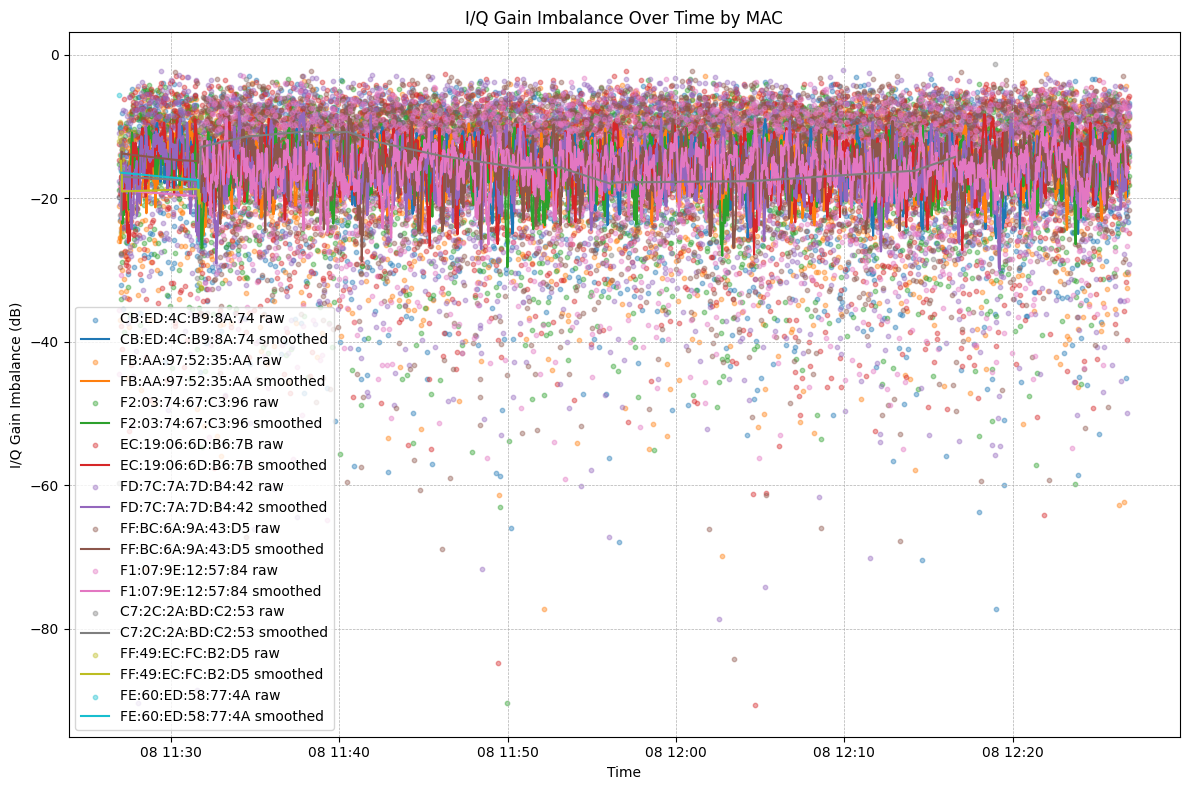

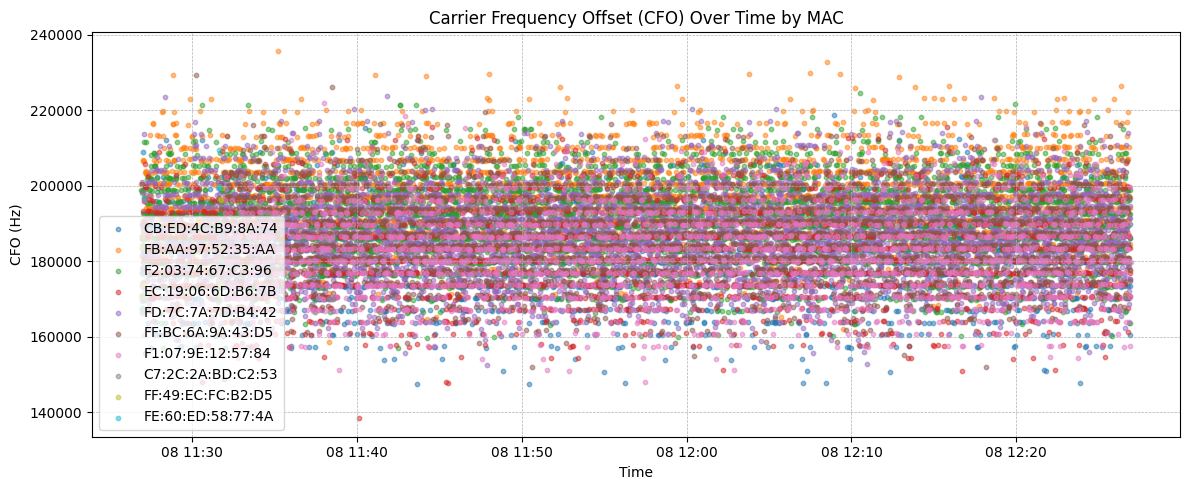

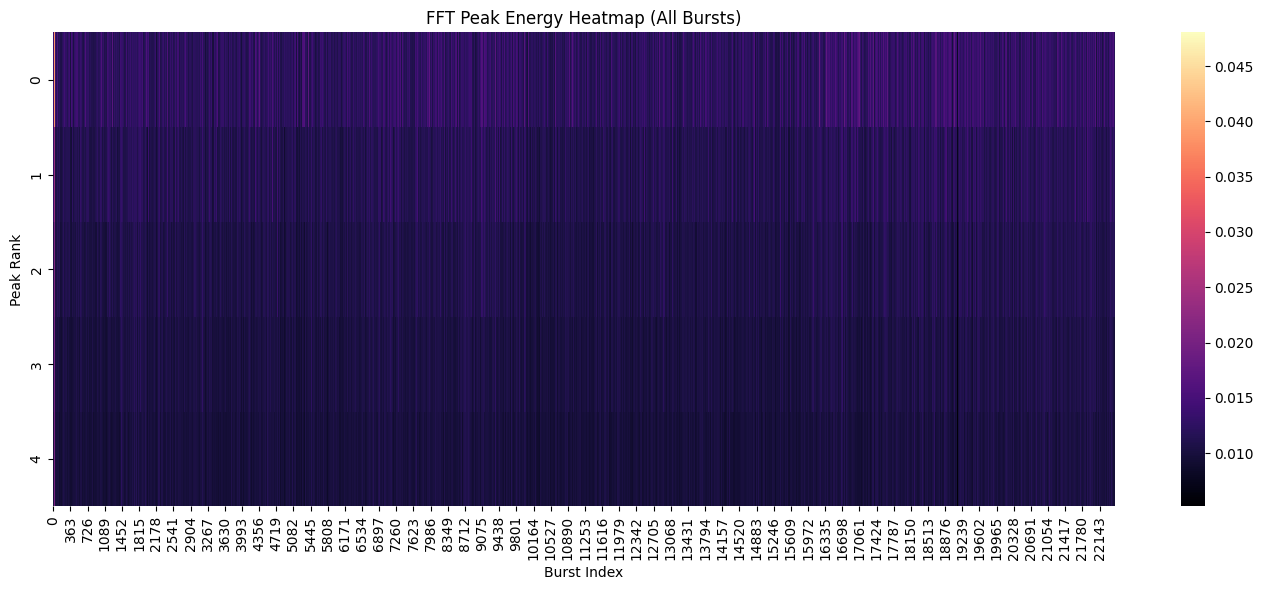

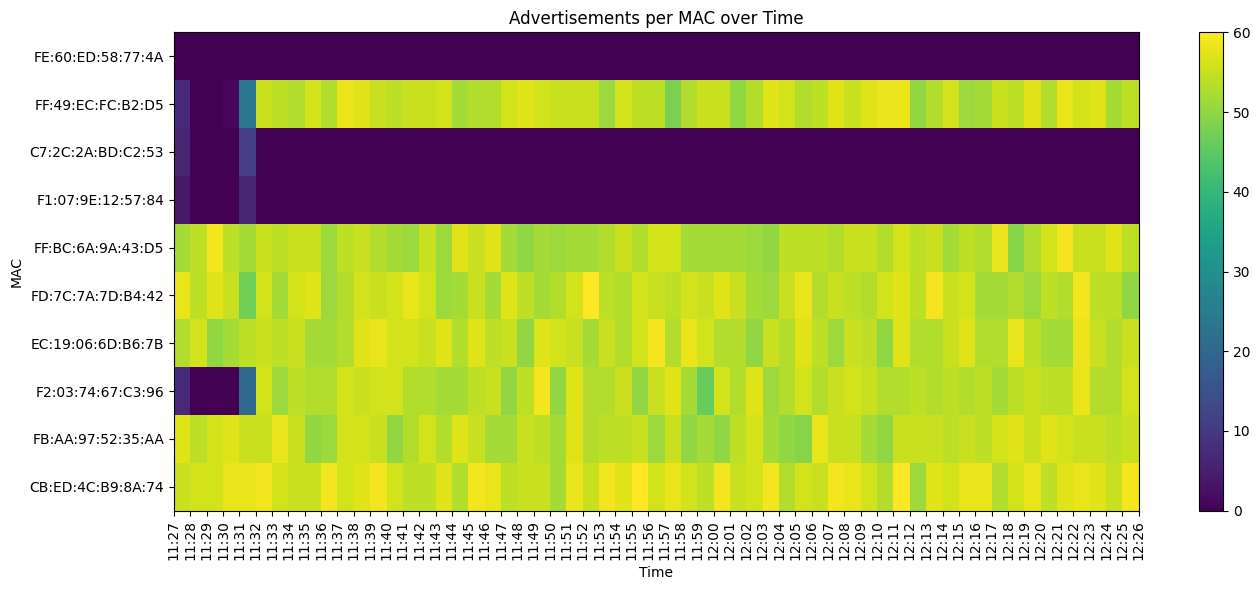

In [2]:
# Print number of adverts per address and plot gain imbalance, CFO drift, FFT peaks and number of adverts over time.

# --- Remove Devices With Few Advertisements
min_adverts = 10 # The minimum number of advertisements for a device to be included

# --- Load Features From Disk
df_features = pd.read_csv("../disk/features.csv")
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

# --- Remove Devices With Few Adverts
hist_mac = df_features['address'].value_counts()
print(hist_mac)
top_macs = hist_mac[hist_mac > min_adverts].index
df_features = df_features[df_features['address'].isin(top_macs)]

# --- Plot Gain Imbalance
plt.figure(figsize=(12, 8))
for mac in top_macs:  # Assume you already have 'top_macs'
    subset = df_features[df_features['address'] == mac]
    subset = subset.sort_values('timestamp')
    subset['iq_gain_imbalance_db'] = 20 * np.log10(np.abs(subset['iq_gain_imbalance_db']) + 1e-10)
    
    # Optional smoothing
    subset['smoothed'] = subset['iq_gain_imbalance_db'].rolling(window=10, center=True).mean()
    
    plt.scatter(subset['timestamp'], subset['iq_gain_imbalance_db'], s=10, alpha=0.4, label=f"{mac} raw")
    plt.plot(subset['timestamp'], subset['smoothed'], label=f"{mac} smoothed")

plt.ylabel("I/Q Gain Imbalance (dB)")
plt.xlabel("Time")
plt.title("I/Q Gain Imbalance Over Time by MAC")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Plot CFO Drift
plt.figure(figsize=(12, 5))

for mac in top_macs:
    subset = df_features[df_features['address'] == mac]
    subset = subset.sort_values('timestamp')
    
    plt.scatter(subset['timestamp'], subset['cfo_estimate_hz'], s=10, alpha=0.5, label=mac)

plt.ylabel("CFO (Hz)")
plt.xlabel("Time")
plt.title("Carrier Frequency Offset (CFO) Over Time by MAC")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Plot FFT Peaks
fft_peaks_cols = [col for col in df_features.columns if col.startswith('fft_peak_')]
fft_matrix = df_features[fft_peaks_cols].values

plt.figure(figsize=(14, 6))
sns.heatmap(fft_matrix.T, cmap="magma", cbar=True)
plt.title("FFT Peak Energy Heatmap (All Bursts)")
plt.xlabel("Burst Index")
plt.ylabel("Peak Rank")
plt.tight_layout()
plt.show()

# --- Plot Number of Adverts over Time
fig, ax = plt.subplots(figsize=(14, 6))

start_time = df_features['timestamp'].min().ceil('1min')
end_time = df_features['timestamp'].max().floor('1min')
df_features['address_id'] = pd.factorize(df_features['address'])[0]
_, xedges, yedges, img = plt.hist2d(
    df_features['timestamp'], df_features['address_id'],
    bins = [np.array(pd.date_range(start_time, end_time, freq='1min')), np.array(range(1, len(top_macs)+2))-0.5]
)
plt.colorbar(img, ax=ax)

plt.xticks(xedges, labels=pd.date_range(start_time, end_time, freq='1min').strftime('%H:%M'), rotation=90)
plt.yticks(range(1,len(top_macs)+1), labels=top_macs)

plt.title("Advertisements per MAC over Time")
plt.xlabel("Time")
plt.ylabel("MAC")
plt.tight_layout()
plt.show()

? X_scaled shape: (22463, 19), MAC labels shape: (22463,)


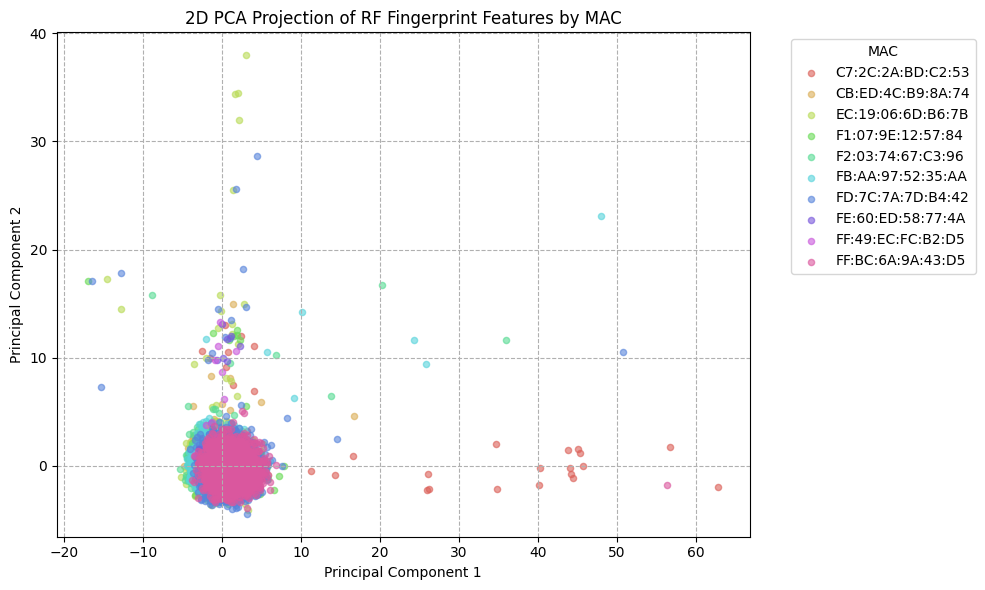

In [3]:
# --- Setup

# --- Remove Devices With Few Advertisements
min_adverts = 10 # The minimum number of advertisements for a device to be included

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Load Features and Labeled MACs
df_features = pd.read_csv("../disk/features.csv")
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

# --- Remove Devices With Few Adverts
hist_mac = df_features['address'].value_counts()
top_macs = hist_mac[hist_mac > min_adverts].index
df_features = df_features[df_features['address'].isin(top_macs)]

# --- Select Numeric Feature Columns
exclude_cols = ['timestamp', 'address', 'address_id']
feature_cols = [
    col for col in df_features.columns
    if col not in exclude_cols # and not isinstance(df_features[col].iloc[0], (str, dict, list)) # TODO: <- do we need this? 
]

# --- Scale Features
X = df_features[feature_cols].dropna()
mac_labels = df_features.loc[X.index, 'address'].astype(str).values  # Align correctly!

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"? X_scaled shape: {X_scaled.shape}, MAC labels shape: {mac_labels.shape}")

# --- PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Plot PCA
plt.figure(figsize=(10, 6))
unique_macs = sorted(pd.Series(mac_labels).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels == mac)
    if np.sum(idx) > 0:
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=20, alpha=0.6, label=mac, color=palette[i % len(palette)])

plt.title("2D PCA Projection of RF Fingerprint Features by MAC")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--")
plt.legend(title="MAC", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


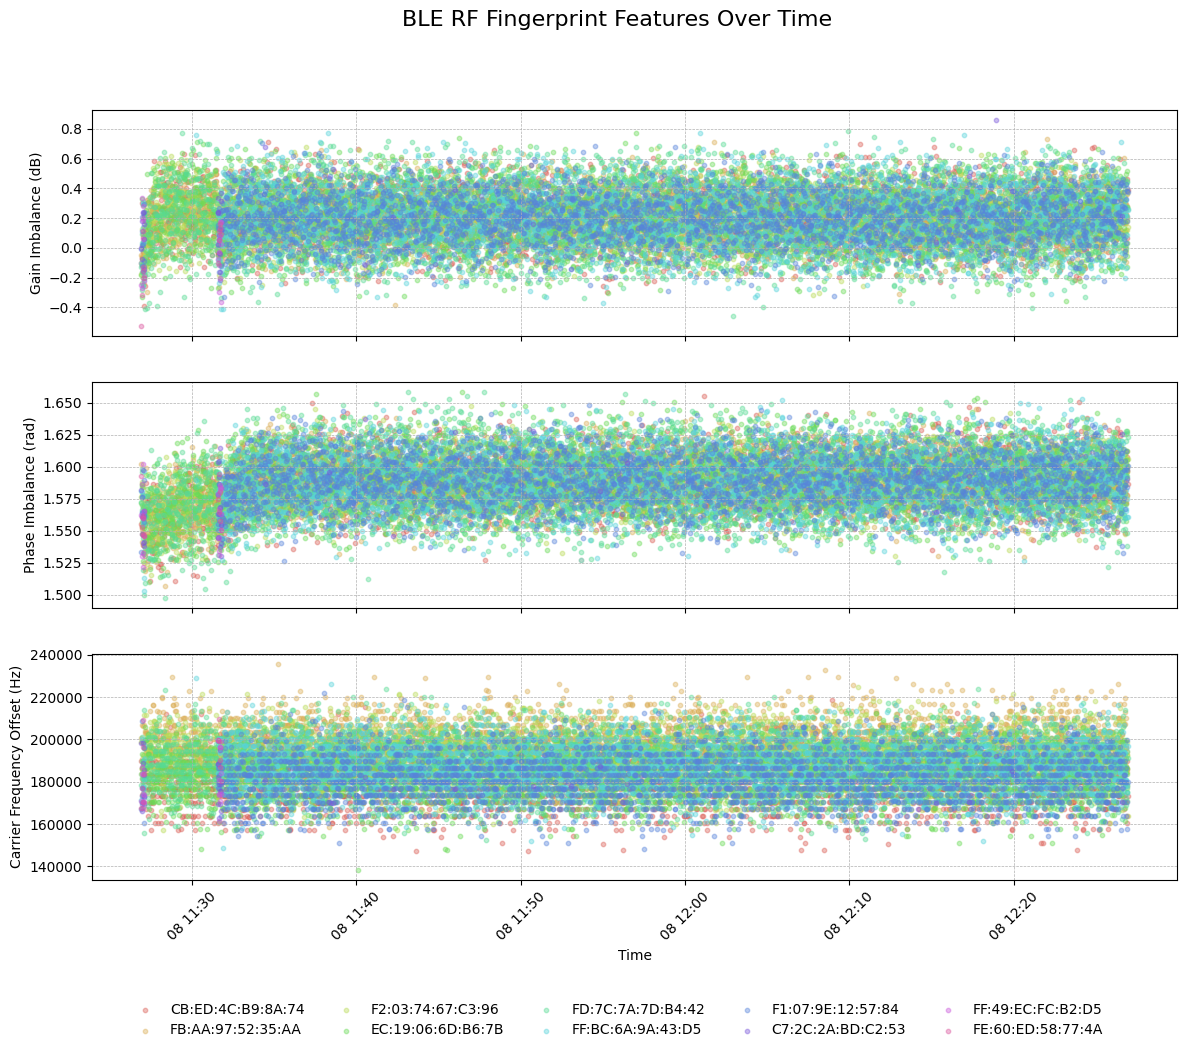

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Metrics and their new axis labels
plot_fields = {
    "iq_gain_imbalance_db": "Gain Imbalance (dB)",
    "iq_phase_imbalance_rad": "Phase Imbalance (rad)",
    "cfo_estimate_hz": "Carrier Frequency Offset (Hz)"
}

# Plotting
for plot_nr, (ax, (field, label)) in enumerate(zip(axs, plot_fields.items())):
    for i, mac in enumerate(top_macs):
        subset = df_features[df_features['address'] == mac].copy()
        subset = subset.sort_values("timestamp")

        # Optional: outlier filtering for visual clarity
        if "imbalance" in field:
            subset = subset[np.abs(subset[field]) < 100]

        ax.scatter(
            subset['timestamp'], subset[field],
            s=10, alpha=0.4, label=mac if not plot_nr else '', color=palette[i]
        )

    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.set_yscale("linear")  # CFO is linear in Hz; imbalance metrics also okay on linear

# Shared x-axis and legend
axs[-1].set_xlabel("Time")
fig.suptitle("BLE RF Fingerprint Features Over Time", fontsize=16)
plt.xticks(rotation=45)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=len(top_macs)/2, frameon=False)
plt.show()

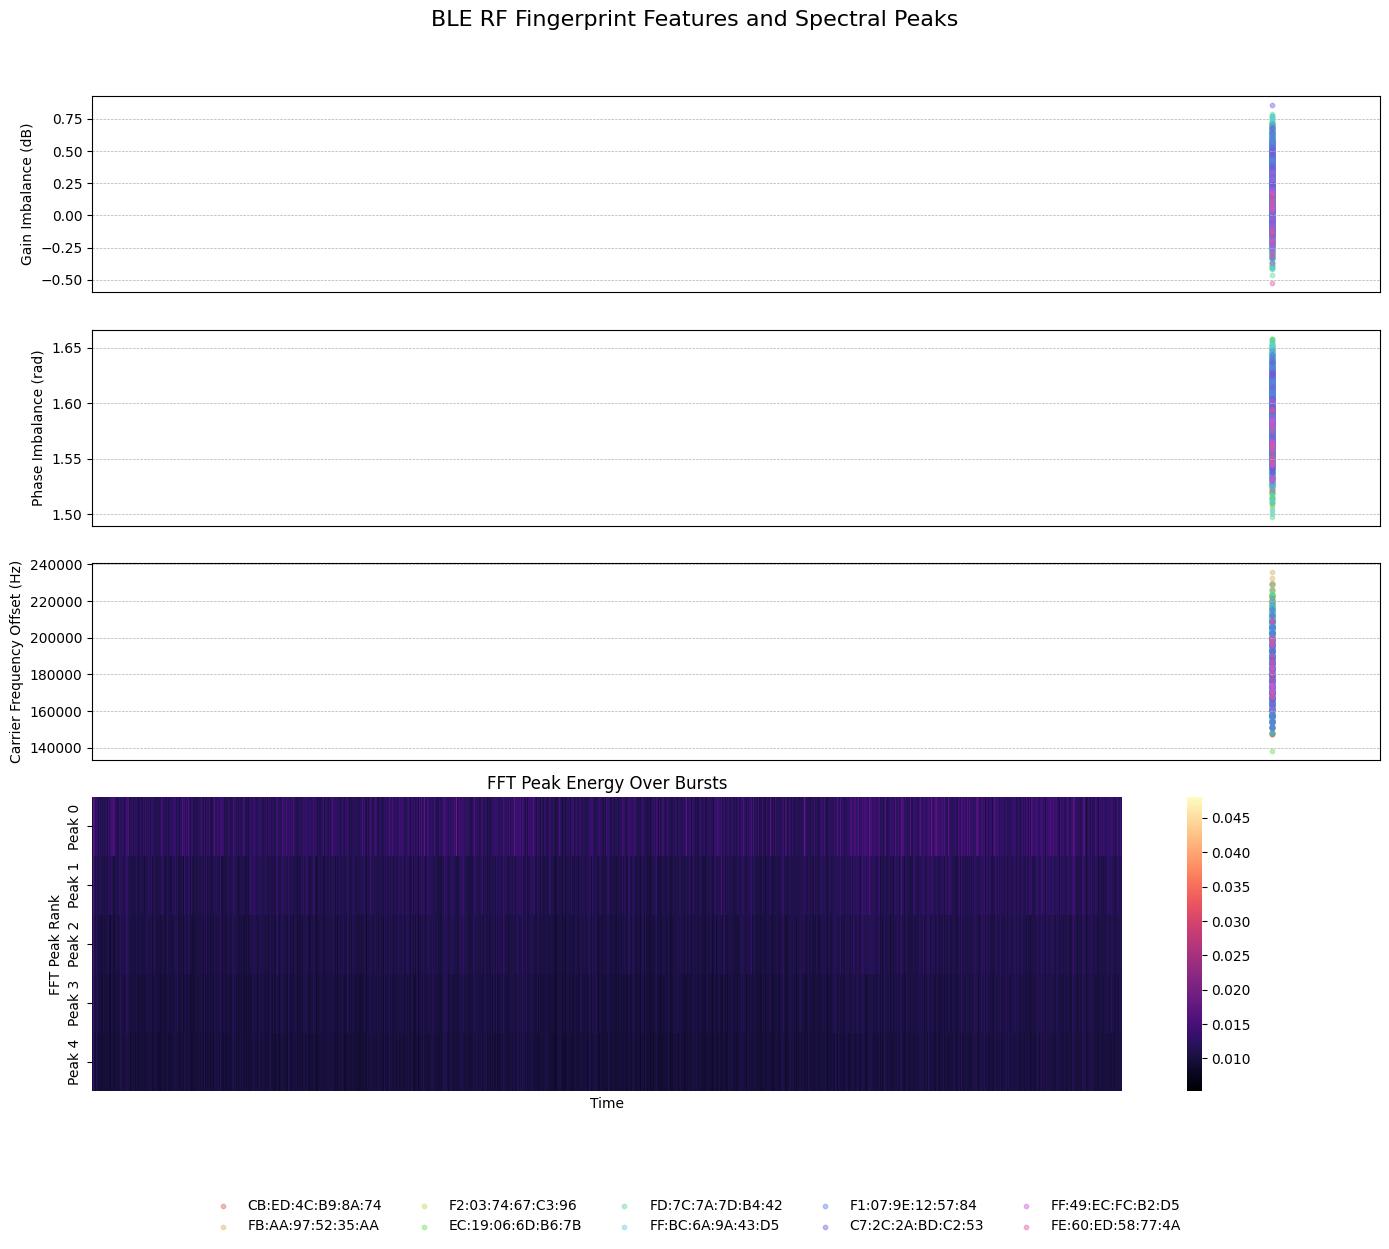

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prepare FFT peak data
fft_cols = [col for col in df_features.columns if col.startswith("fft_peak")]
fft_matrix = df_features[fft_cols].to_numpy().T  # shape: [peaks, bursts]
timestamps = df_features['timestamp']

# --- Subplots: 3 features + 1 heatmap = 4 rows
fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 1.5]})

plot_fields = {
    "iq_gain_imbalance_db": "Gain Imbalance (dB)",
    "iq_phase_imbalance_rad": "Phase Imbalance (rad)",
    "cfo_estimate_hz": "Carrier Frequency Offset (Hz)"
}

# --- Feature Time Series
for plot_nr, (ax, (field, label)) in enumerate(zip(axs[:3], plot_fields.items())):
    for i, mac in enumerate(top_macs):
        subset = df_features[df_features['address'] == mac].copy()
        subset = subset.sort_values("timestamp")
        if "imbalance" in field:
            subset = subset[np.abs(subset[field]) < 100]
        ax.scatter(subset['timestamp'], subset[field], s=10, alpha=0.4, label=mac if not plot_nr else '', color=palette[i])
    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", linewidth=0.5)

# --- FFT Peak Heatmap
sns.heatmap(
    fft_matrix,
    cmap="magma",
    ax=axs[3],
    cbar=True,
    xticklabels=False,
    yticklabels=[f"Peak {i}" for i in range(len(fft_cols))]
)
axs[3].set_ylabel("FFT Peak Rank")
axs[3].set_title("FFT Peak Energy Over Bursts")

# --- Common axis formatting
axs[-1].set_xlabel("Time")
fig.suptitle("BLE RF Fingerprint Features and Spectral Peaks", fontsize=16)
plt.xticks(rotation=45)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=len(top_macs)/2, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()



? X_clean shape: (22463, 19), mac_labels_clean shape: (22463,)


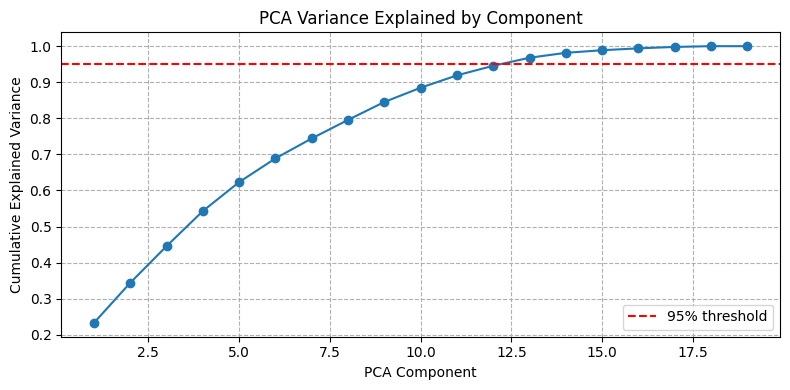

? Top contributing features to PC1:


,PC1,PC2,PC3
fft_peak_3,0.438783,0.002066,0.008538
fft_peak_2,0.437113,0.012167,0.004842
fft_peak_4,0.422344,0.000877,0.007168
fft_peak_1,0.411734,0.012896,0.000535
spectral_entropy,0.367197,0.000564,0.008116
fft_peak_0,0.339258,0.014752,0.004399
phase_noise,0.085073,0.135785,0.006451
time_entropy,0.072829,0.346499,0.077831
rms_power,0.051900,0.141851,0.028817
cfo_estimate_hz,0.042247,0.036833,0.009146


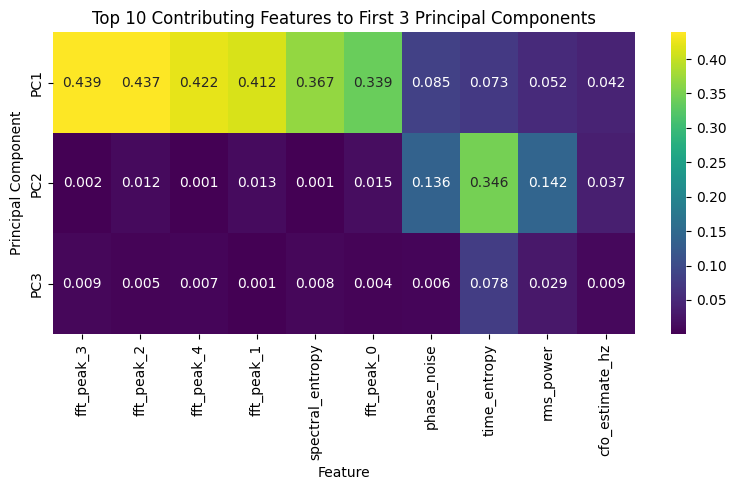

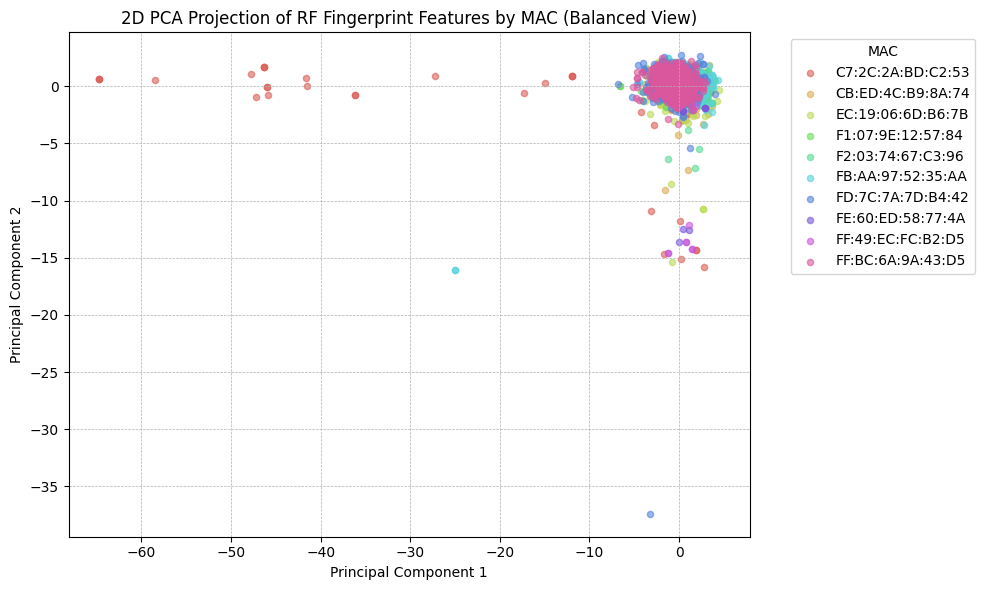

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Select numeric features
exclude_cols = ['timestamp', 'burst_timestamp', 'matched_macs', 'matched_rssi']
feature_cols = [
    col for col in df_features.columns
    if col not in exclude_cols and not isinstance(df_features[col].iloc[0], (str, dict, list))
]

# --- Clean NaNs and match labels
X_raw = df_features[feature_cols]
mac_labels_raw = df_features['address'].fillna("Unknown").astype(str)
valid_idx = X_raw.dropna().index
X_clean = X_raw.loc[valid_idx]
mac_labels_clean = mac_labels_raw.loc[valid_idx]

print(f"? X_clean shape: {X_clean.shape}, mac_labels_clean shape: {mac_labels_clean.shape}")

# --- Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# --- Full PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Plot cumulative variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained by Component")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

# --- Top contributing features to first 3 PCs
loading_matrix = pd.DataFrame(
    pca_full.components_[:3],
    columns=X_clean.columns,
    index=["PC1", "PC2", "PC3"]
)
top_features = loading_matrix.abs().T.sort_values("PC1", ascending=False).head(10)
print("? Top contributing features to PC1:")
display(top_features)

# --- Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(top_features.T, annot=True, fmt=".3f", cmap="viridis", cbar=True)
plt.title("Top 10 Contributing Features to First 3 Principal Components")
plt.xlabel("Feature")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()

# --- 2D PCA visualization with optional balancing
from sklearn.utils import resample
df_vis = pd.DataFrame(X_scaled, columns=feature_cols, index=X_clean.index)
df_vis["mac"] = mac_labels_clean

# Take max 500 samples per MAC
df_samples = pd.concat([
    resample(g, n_samples=min(500, len(g)), random_state=42)
    for _, g in df_vis.groupby("mac")
])

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(df_samples[feature_cols])
mac_labels_vis = df_samples["mac"].values

# --- 2D scatter plot
plt.figure(figsize=(10, 6))
unique_macs = sorted(pd.Series(mac_labels_vis).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels_vis == mac)
    plt.scatter(X_vis[idx, 0], X_vis[idx, 1], s=20, alpha=0.6,
                label=mac, color=palette[i % len(palette)])

plt.title("2D PCA Projection of RF Fingerprint Features by MAC (Balanced View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend(title="MAC", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


X_clean shape: (22463, 19), MAC labels: (22463,)


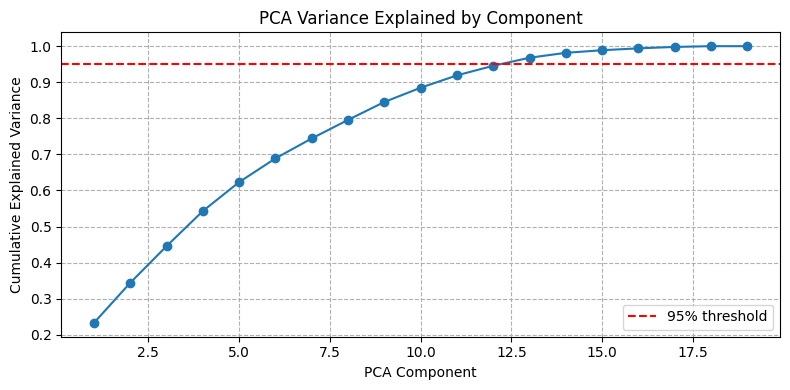

? Components needed for >=95% variance: 13
? Top contributing features to PC1:


,PC1,PC2,PC3
fft_peak_3,0.438783,0.002066,0.008538
fft_peak_2,0.437113,0.012167,0.004842
fft_peak_4,0.422344,0.000877,0.007168
fft_peak_1,0.411734,0.012896,0.000535
spectral_entropy,0.367197,0.000564,0.008116
fft_peak_0,0.339258,0.014752,0.004399
phase_noise,0.085073,0.135785,0.006451
time_entropy,0.072829,0.346499,0.077831
rms_power,0.051900,0.141851,0.028817
cfo_estimate_hz,0.042247,0.036833,0.009146


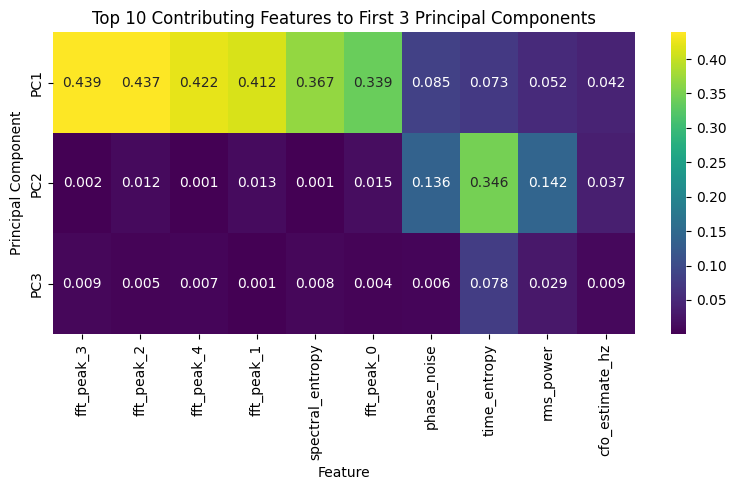

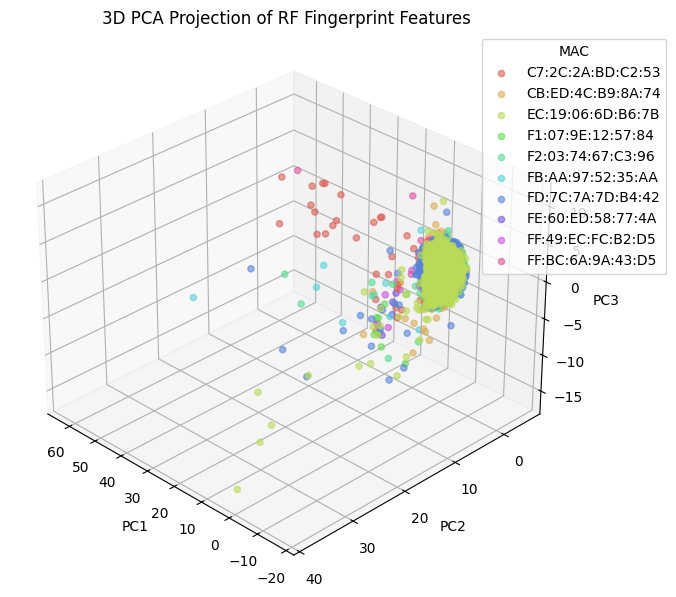

In [7]:
# --- Setup
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# --- Select numeric features
exclude_cols = ['timestamp', 'burst_timestamp', 'matched_macs', 'matched_rssi']
feature_cols = [
    col for col in df_features.columns
    if col not in exclude_cols and not isinstance(df_features[col].iloc[0], (str, dict, list))
]

# --- Prepare and scale data
X = df_features[feature_cols]
mac_labels_all = df_features['address'].fillna("Unknown").astype(str)

# Drop rows with NaN (for both X and MAC labels)
X_clean = X.dropna()
mac_labels_clean = mac_labels_all.loc[X_clean.index].values  # <-- MATCH the cleaned index

print(f"X_clean shape: {X_clean.shape}, MAC labels: {mac_labels_clean.shape}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# --- Full PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained by Component")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

# --- Identify how many PCs needed
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"? Components needed for >=95% variance: {n_components}")

# --- Top contributing features
loading_matrix = pd.DataFrame(
    pca_full.components_[:3], columns=feature_cols, index=["PC1", "PC2", "PC3"]
)
top_features = loading_matrix.abs().T.sort_values("PC1", ascending=False).head(10)

print("? Top contributing features to PC1:")
display(top_features)

# --- Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(top_features.T, annot=True, fmt=".3f", cmap="viridis", cbar=True)
plt.title("Top 10 Contributing Features to First 3 Principal Components")
plt.xlabel("Feature")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()

# --- 3D PCA projection
pca_vis = PCA(n_components=3)
X_vis = pca_vis.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
unique_macs = sorted(pd.Series(mac_labels_clean).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels_clean == mac)
    ax.scatter(X_vis[idx, 0], X_vis[idx, 1], X_vis[idx, 2],
               label=mac, alpha=0.6, s=20, color=palette[i % len(palette)])

ax.set_title("3D PCA Projection of RF Fingerprint Features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.view_init(elev=30, azim=135)
ax.legend(title="MAC", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()
